In [2]:
%pip install google-cloud-bigquery

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 5.1 MB/s  0:00:02a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 6.9 MB/s  0:00:00m 9.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [google-cloud-bigquery] 9/13 [google-auth]rotos]
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("/Users/tamannarawat/Downloads/regional_sustainability_score.csv")

In [2]:
df.head()

,region_id,region_name,cloud_region,scored_year,cfe_percent,grid_carbon_intensity,cfe_change_percentage_points,sustainability_score
0,SE,Sweden,europe-north2,2024,100,2.73,NaN,100.00
1,NO,Norway,non-cloud-data-center,2024,100,6.11,NaN,99.81
2,CH,Switzerland,europe-west6,2024,98,15.05,6.0,88.61
3,CA-QC,Quebec,northamerica-northeast1,2024,99,5.48,-1.0,87.38
4,FR,France,europe-west9,2024,96,16.30,2.0,86.32


In [3]:
df.shape

(54, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   region_id                     54 non-null     object 
 1   region_name                   54 non-null     object 
 2   cloud_region                  54 non-null     object 
 3   scored_year                   54 non-null     int64  
 4   cfe_percent                   54 non-null     int64  
 5   grid_carbon_intensity         54 non-null     float64
 6   cfe_change_percentage_points  43 non-null     float64
 7   sustainability_score          54 non-null     float64
dtypes: float64(3), int64(2), object(3)
memory usage: 3.5+ KB


In [7]:
df.isnull().sum()

region_id                        0
region_name                      0
cloud_region                     0
scored_year                      0
cfe_percent                      0
grid_carbon_intensity            0
cfe_change_percentage_points    11
sustainability_score             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

# Analysis

In [16]:
#Top 10 sustainable region
top_10=df.sort_values('sustainability_score',ascending=False).head(10)

In [17]:
#Bottom 10 sustainable region
bottom_10=df.sort_values('sustainability_score').head(10)

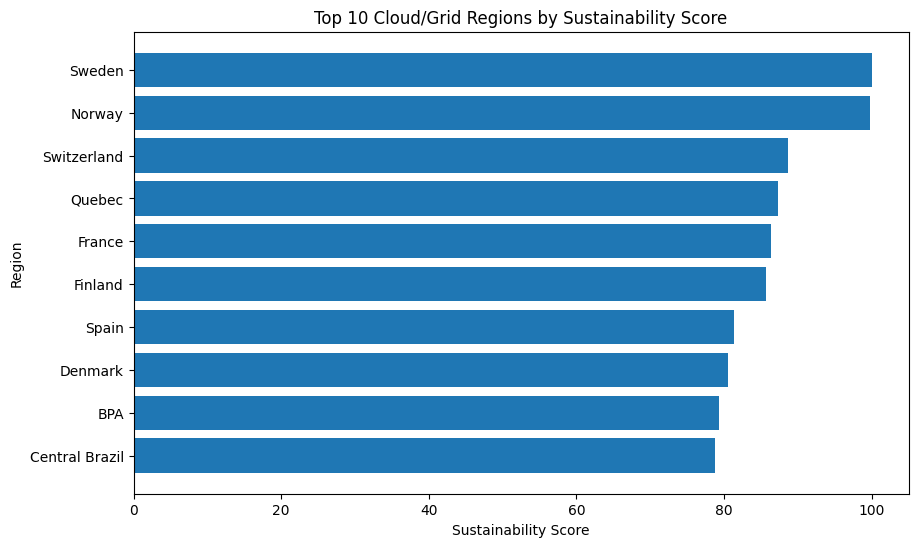

In [18]:
#Visualization
top_10_plot = top_10.sort_values(
    "sustainability_score"
)
plt.figure(figsize=(10, 6))
plt.barh(
    top_10_plot["region_name"],
    top_10_plot["sustainability_score"]
)
plt.xlabel("Sustainability Score")
plt.ylabel("Region")
plt.title("Top 10 Cloud/Grid Regions by Sustainability Score")
plt.show()

# Historical data

In [19]:
energy_df=pd.read_csv('/Users/tamannarawat/Downloads/energy_clean.csv')

In [20]:
energy_df.head()

,year,cfe_region,zone_id,cloud_region,location,google_cfe,grid_carbon_intensity,cfe_data_status,carbon_data_status
0,2019,New South Wales,AUS-NSW,australia-southeast1,Sydney,0.11,725.0,Available,Available
1,2019,Belgium,BE,europe-west1,Belgium,0.68,196.0,Available,Available
2,2019,Central Brazil,BR-CS,southamerica-east1,São Paulo,0.87,109.0,Available,Available
3,2019,Quebec,CA-QC,northamerica-northeast1,Montréal,NaN,27.0,Missing,Available
4,2019,Switzerland,CH,europe-west6,Zurich,NaN,87.0,Missing,Available


In [21]:
energy_df.shape

(237, 9)

In [22]:
energy_df.isnull().sum()

year                      0
cfe_region                0
zone_id                   0
cloud_region              1
location                  6
google_cfe               16
grid_carbon_intensity     1
cfe_data_status           0
carbon_data_status        0
dtype: int64

In [23]:
energy_df.duplicated().sum()

np.int64(0)

In [24]:
energy_df["cfe_percent"] = energy_df["google_cfe"] * 100

In [25]:
energy_df

,year,cfe_region,zone_id,cloud_region,location,google_cfe,grid_carbon_intensity,cfe_data_status,carbon_data_status,cfe_percent
0,2019,New South Wales,AUS-NSW,australia-southeast1,Sydney,0.11,725.00,Available,Available,11.0
1,2019,Belgium,BE,europe-west1,Belgium,0.68,196.00,Available,Available,68.0
2,2019,Central Brazil,BR-CS,southamerica-east1,São Paulo,0.87,109.00,Available,Available,87.0
3,2019,Quebec,CA-QC,northamerica-northeast1,Montréal,NaN,27.00,Missing,Available,NaN
4,2019,Switzerland,CH,europe-west6,Zurich,NaN,87.00,Missing,Available,NaN
...,...,...,...,...,...,...,...,...,...,...
232,2024,SOCO,US-SE-SOCO,us-east2,Georgia,0.42,340.42,Available,Available,42.0
233,2024,AZ-SRP,US-SW-SRP,non-cloud-data-center,Phoenix,0.52,243.46,Available,Available,52.0
234,2024,TVA,US-TEN-TVA,us-east7,Alabama and Tennessee,0.63,310.28,Available,Available,63.0
235,2024,ERCOT,US-TEX-ERCO,us-south1,Dallas,0.94,302.95,Available,Available,94.0


In [28]:
#cfe level changes over years
yearly_cfe=energy_df.groupby('year')['cfe_percent'].mean().reset_index()
yearly_cfe

,year,cfe_percent
0,2019,50.409091
1,2020,52.185185
2,2021,47.741935
3,2022,53.809524
4,2023,54.354167
5,2024,56.921569


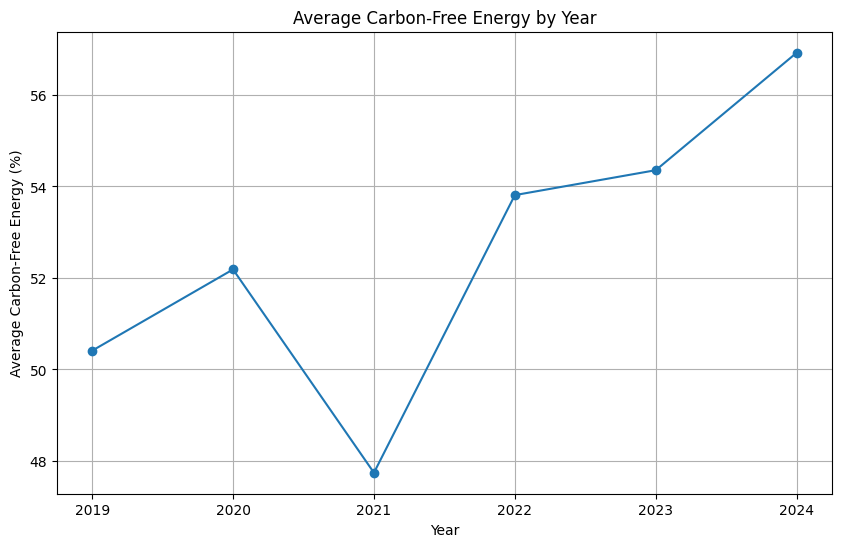

In [30]:
#Visualization
plt.figure(figsize=(10,6))
plt.plot(
    yearly_cfe["year"],
    yearly_cfe["cfe_percent"],
    marker="o"
)
plt.xlabel("Year")
plt.ylabel("Average Carbon-Free Energy (%)")
plt.title("Average Carbon-Free Energy by Year")
plt.grid(True)
plt.show()

In [31]:
improvement = (
    energy_df
    .dropna(subset=["google_cfe"])
    .sort_values(["zone_id", "year"])
    .copy())
improvement["previous_cfe"] = (
    improvement
    .groupby("zone_id")["google_cfe"]
    .shift(1))
improvement["cfe_change_pp"] = (
    (improvement["google_cfe"] - improvement["previous_cfe"]) * 100)
improvement[
    [
        "cfe_region",
        "zone_id",
        "year",
        "cfe_change_pp"
    ]
].sort_values(
    "cfe_change_pp",
    ascending=False
).head(10)

,cfe_region,zone_id,year,cfe_change_pp
184,ERCOT,US-TEX-ERCO,2023,38.0
230,NVE,US-NW-NEVP,2024,38.0
104,Germany,DE,2022,36.0
110,Great Britain,GB,2022,28.0
165,Netherlands,NL,2023,23.0
208,Italy,IT,2024,21.0
103,Chile,CL-SEN,2022,20.0
54,PJM,US-MIDA-PJM,2020,17.0
38,Finland,FI,2020,17.0
210,Kansai,JP-KN,2024,16.0


In [32]:
#Region with largest decline in cfe
decline = (
    improvement[
        improvement["previous_cfe"].notna()
    ]
    .sort_values("cfe_change_pp", ascending=True))
decline[
    [
        "cfe_region",
        "zone_id",
        "year",
        "cfe_change_pp"
    ]
].head(10)

,cfe_region,zone_id,year,cfe_change_pp
202,Hong Kong,HK,2024,-27.0
194,Germany,DE,2024,-22.0
201,Great Britain,GB,2024,-13.0
65,Central Brazil,BR-CS,2021,-10.0
159,Maharashtra,IN-WE,2023,-10.0
176,PJM,US-MIDA-PJM,2023,-8.0
228,MISO,US-MIDW-MISO,2024,-8.0
113,Ireland,IE,2022,-7.0
83,Netherlands,NL,2021,-7.0
135,TVA,US-TEN-TVA,2022,-7.0


In [33]:
# region with lowest carbon grid 
lowest_carbon = (
    energy_df
    .dropna(subset=["grid_carbon_intensity"])
    .sort_values("grid_carbon_intensity")
    .head(10))
lowest_carbon[
    [
        "cfe_region",
        "zone_id",
        "year",
        "grid_carbon_intensity"
    ]
]

,cfe_region,zone_id,year,grid_carbon_intensity
67,Quebec,CA-QC,2021,0.00
101,Quebec,CA-QC,2022,0.25
143,Quebec,CA-QC,2023,1.78
219,Sweden,SE,2024,2.73
191,Quebec,CA-QC,2024,5.48
215,Norway,NO,2024,6.11
192,Switzerland,CH,2024,15.05
200,France,FR,2024,16.30
3,Quebec,CA-QC,2019,27.00
33,Quebec,CA-QC,2020,27.00


In [34]:
#Region with highest carbon grid 
highest_carbon = (
    energy_df
    .dropna(subset=["grid_carbon_intensity"])
    .sort_values("grid_carbon_intensity", ascending=False)
    .head(10))
highest_carbon[
    [
        "cfe_region",
        "zone_id",
        "year",
        "grid_carbon_intensity"
    ]
]

,cfe_region,zone_id,year,grid_carbon_intensity
12,Maharashtra,IN-MH,2019,752.00
122,Poland,PL,2022,737.84
30,New South Wales,AUS-NSW,2020,727.00
0,New South Wales,AUS-NSW,2019,725.00
166,Poland,PL,2023,723.34
43,Maharashtra,IN-MH,2020,721.00
207,Western India,IN-WE,2024,678.76
78,Uttar Pradesh,IN-UP,2021,671.00
77,Maharashtra,IN-MH,2021,670.00
236,South Africa,ZA,2024,656.85


In [35]:
#CFE Vs Grid carbon intensity
correlation_df = (
    energy_df[
        ["cfe_percent", "grid_carbon_intensity"]
    ]
    .dropna()
)

correlation = correlation_df[
    "cfe_percent"
].corr(
    correlation_df["grid_carbon_intensity"]
)

correlation

np.float64(-0.7805702980051581)

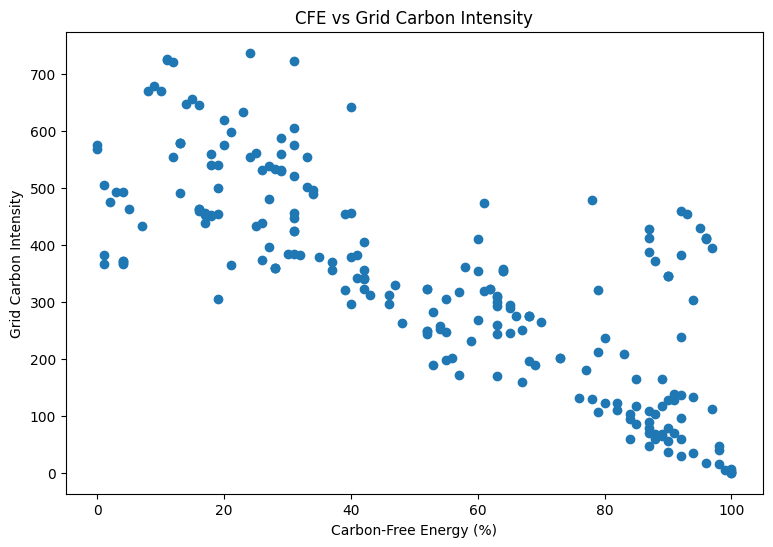

In [36]:
# Visualization
plt.figure(figsize=(9, 6))
plt.scatter(
    correlation_df["cfe_percent"],
    correlation_df["grid_carbon_intensity"]
)

plt.xlabel("Carbon-Free Energy (%)")
plt.ylabel("Grid Carbon Intensity")
plt.title("CFE vs Grid Carbon Intensity")

plt.show()